<a href="https://colab.research.google.com/github/casimiro10/transfer-learning-gatos-cachorros/blob/main/transfer_learning_gatos_cachorros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
print("Versao do TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU disponivel:", gpus)
else:
    print("Nenhuma GPU encontrada - o treino vai funcionar, mas bem mais devagar.")

Versao do TensorFlow: 2.21.0
Nenhuma GPU encontrada - o treino vai funcionar, mas bem mais devagar.


In [20]:
(train_ds_raw, val_ds_raw, test_ds_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    as_supervised=True,
    with_info=True,
)

class_names = info.features['label'].names
print("Classes:", class_names)
print("Total de imagens:", info.splits['train'].num_examples)

Classes: ['cat', 'dog']
Total de imagens: 23262


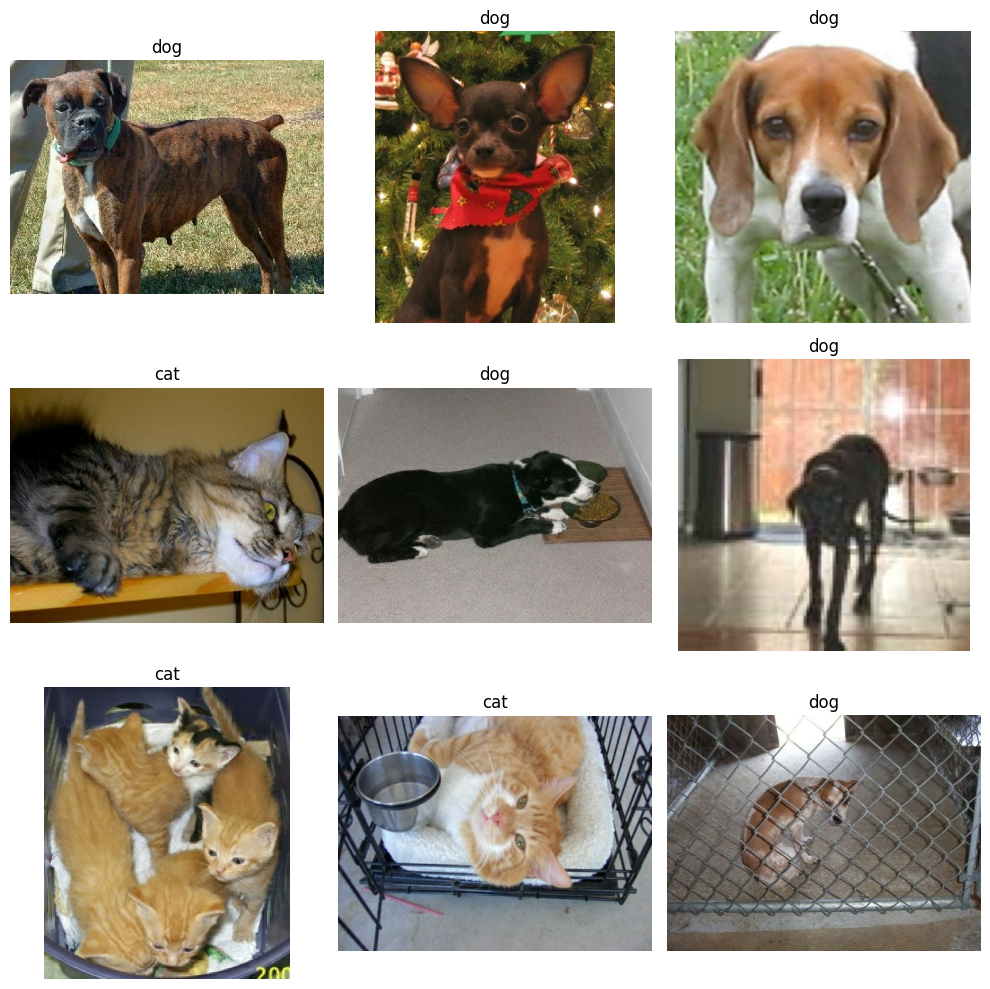

In [21]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds_raw.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(class_names[label.numpy()])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [22]:
IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preparar(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = (train_ds_raw.map(preparar, num_parallel_calls=AUTOTUNE)
            .shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds = (val_ds_raw.map(preparar, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))
test_ds = (test_ds_raw.map(preparar, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print("Pre-processamento concluido.")

Pre-processamento concluido.


In [23]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 300s 506ms/step - accuracy: 0.8435 - loss: 0.3201 - val_accuracy: 0.9570 - val_loss: 0.1221
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 278s 476ms/step - accuracy: 0.9464 - loss: 0.1396 - val_accuracy: 0.9686 - val_loss: 0.0836
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 295s 505ms/step - accuracy: 0.9560 - loss: 0.1125 - val_accuracy: 0.9759 - val_loss: 0.0701
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 330s 519ms/step - accuracy: 0.9624 - loss: 0.0979 - val_accuracy: 0.9772 - val_loss: 0.0632
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 320s 547ms/step - accuracy: 0.9638 - loss: 0.0920 - val_accuracy: 0.9807 - val_loss: 0.0592
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 306s 524ms/step - accuracy: 0.9664 - loss: 0.0855 - val_accuracy: 0.9811 - val_loss: 0.0561
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 297s 509ms/step - accuracy: 0.9652 - loss: 0.0859 - val_accuracy: 0.9815 - val_loss: 0.0540
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 299s 510ms/step - accuracy: 0.9648 -

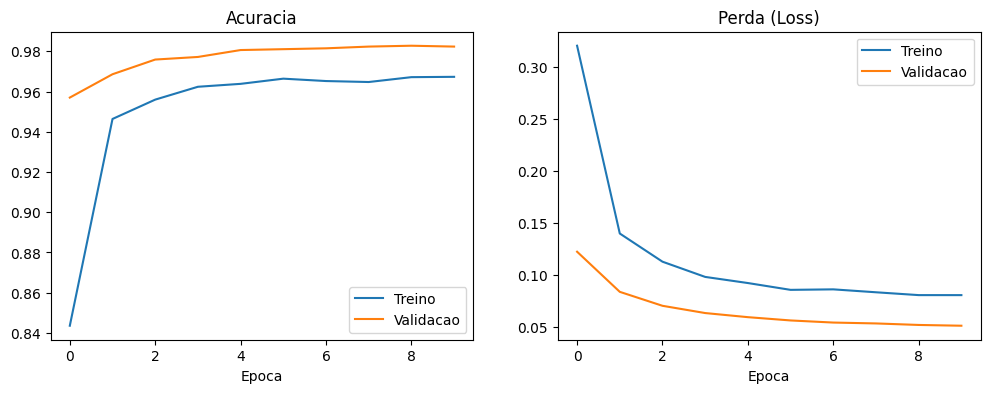

In [26]:
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino'); plt.plot(val_acc, label='Validacao')
plt.title('Acuracia'); plt.xlabel('Epoca'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino'); plt.plot(val_loss, label='Validacao')
plt.title('Perda (Loss)'); plt.xlabel('Epoca'); plt.legend()
plt.show()

In [27]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_fine = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 472s 789ms/step - accuracy: 0.9341 - loss: 0.1664 - val_accuracy: 0.9832 - val_loss: 0.0576
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 464s 796ms/step - accuracy: 0.9592 - loss: 0.0985 - val_accuracy: 0.9845 - val_loss: 0.0486
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 444s 762ms/step - accuracy: 0.9634 - loss: 0.0897 - val_accuracy: 0.9841 - val_loss: 0.0440
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 457s 785ms/step - accuracy: 0.9680 - loss: 0.0792 - val_accuracy: 0.9862 - val_loss: 0.0460
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 444s 761ms/step - accuracy: 0.9710 - loss: 0.0747 - val_accuracy: 0.9845 - val_loss: 0.0430


In [28]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Acuracia no conjunto de teste: {test_acc:.2%}")

73/73 ━━━━━━━━━━━━━━━━━━━━ 29s 389ms/step - accuracy: 0.9841 - loss: 0.0449
Acuracia no conjunto de teste: 98.41%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


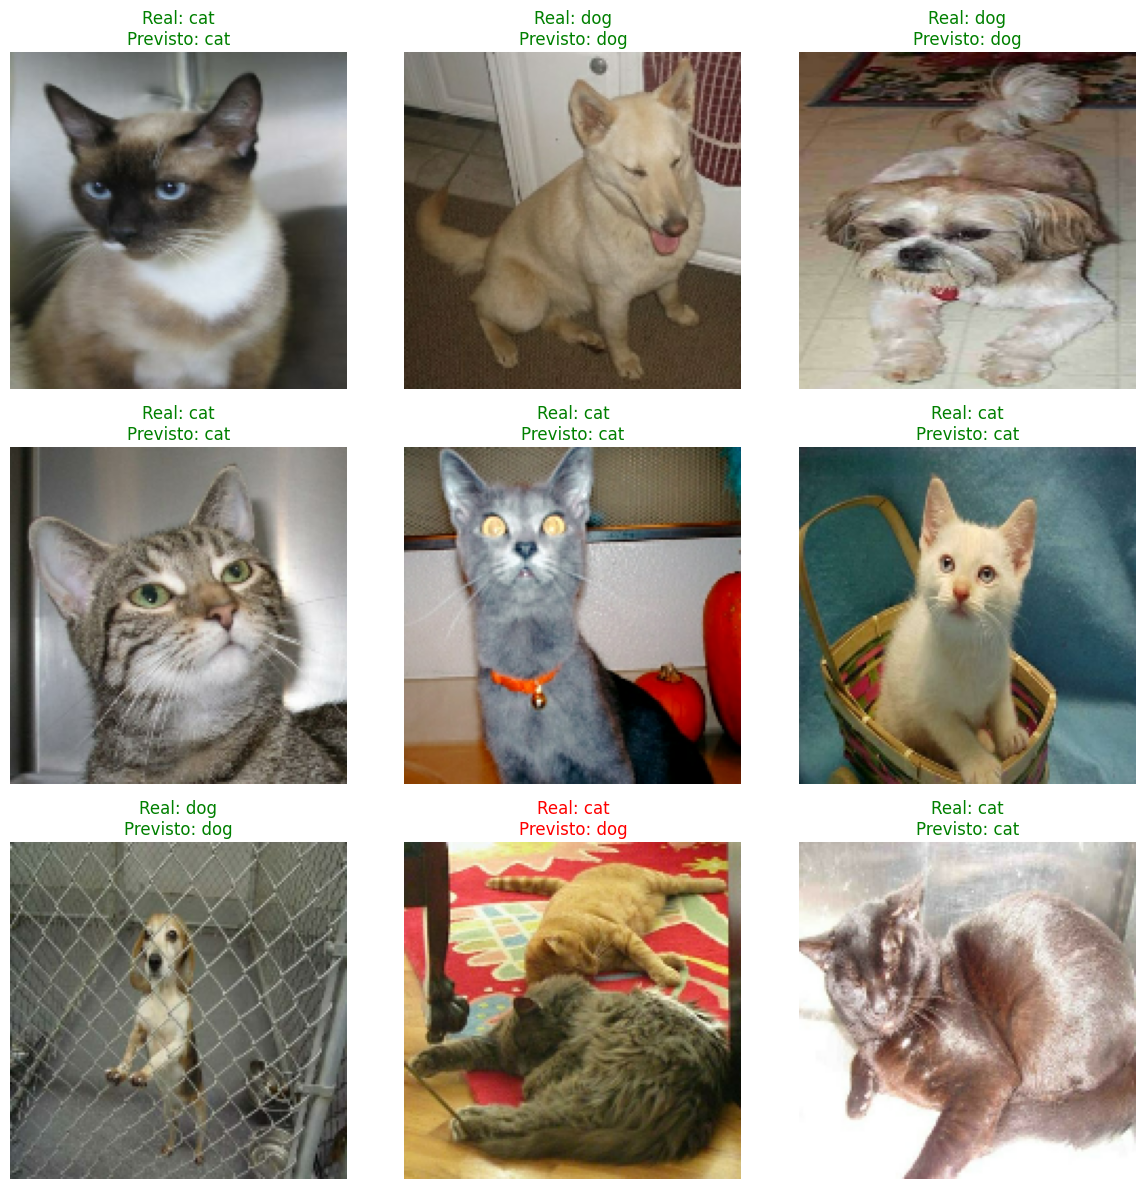

In [29]:
image_batch, label_batch = next(iter(test_ds))
predictions = tf.nn.sigmoid(model.predict(image_batch))
predicted_labels = tf.where(predictions < 0.5, 0, 1).numpy().flatten()

plt.figure(figsize=(12, 12))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    real = class_names[label_batch[i].numpy()]
    previsto = class_names[predicted_labels[i]]
    plt.title(f"Real: {real}\nPrevisto: {previsto}",
              color="green" if real == previsto else "red")
    plt.axis("off")
plt.tight_layout()
plt.show()